<a href="https://www.kaggle.com/code/shamanthakreddymallu/predict-stellar-class-eda?scriptVersionId=324267433" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Imports and Configuration

In [1]:
# PATHS 
TRAIN_PATH    = '/kaggle/input/competitions/playground-series-s6e6/train.csv'
TEST_PATH     = '/kaggle/input/competitions/playground-series-s6e6/test.csv'
ORIGINAL_PATH = '/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/star_classification.csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import balanced_accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='deep')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

CLASS_COLORS = {'GALAXY': '#4C72B0', 'QSO': '#DD8452', 'STAR': '#55A868'}
CLASS_ORDER  = ['GALAXY', 'QSO', 'STAR']
PALETTE      = [CLASS_COLORS[c] for c in CLASS_ORDER]

In [3]:
train    = pd.read_csv(TRAIN_PATH)
test     = pd.read_csv(TEST_PATH)
original = pd.read_csv(ORIGINAL_PATH)

print(f'Train    : {train.shape[0]:,} rows × {train.shape[1]} cols')
print(f'Test     : {test.shape[0]:,} rows × {test.shape[1]} cols')
print(f'Original : {original.shape[0]:,} rows × {original.shape[1]} cols')

print('\nTrain columns    :', train.columns.tolist())
print('Original columns :', original.columns.tolist())

Train    : 577,347 rows × 12 cols
Test     : 247,435 rows × 11 cols
Original : 100,000 rows × 18 cols

Train columns    : ['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'class']
Original columns : ['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift', 'plate', 'MJD', 'fiber_ID']


# Original Dataset — Structure & Target Column

In [4]:
print('Original head:')
display(original.head(3))

print('\nOriginal dtypes:')
print(original.dtypes)

print('\nOriginal target column name and unique values:')
# Original uses 'class' with values 'GALAXY', 'QSO', 'STAR' — verify
target_col = [c for c in original.columns if 'class' in c.lower()][0]
print(f'  Column: "{target_col}"')
print(original[target_col].value_counts())

Original head:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299



Original dtypes:
obj_ID         float64
alpha          float64
delta          float64
u              float64
g              float64
r              float64
i              float64
z              float64
run_ID           int64
rerun_ID         int64
cam_col          int64
field_ID         int64
spec_obj_ID    float64
class           object
redshift       float64
plate            int64
MJD              int64
fiber_ID         int64
dtype: object

Original target column name and unique values:
  Column: "class"
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


# Schema Comparison — What Changed?

In [5]:
orig_cols  = set(original.columns)
train_cols = set(train.columns) - {'class'}  # remove target for fair compare

print('=== Columns in ORIGINAL not in Kaggle train ===')
print(sorted(orig_cols - train_cols))

print('\n=== Columns in Kaggle train not in ORIGINAL ===')
print(sorted(train_cols - orig_cols))

print('\n=== Shared columns ===')
print(sorted(orig_cols & train_cols))

=== Columns in ORIGINAL not in Kaggle train ===
['MJD', 'cam_col', 'class', 'fiber_ID', 'field_ID', 'obj_ID', 'plate', 'rerun_ID', 'run_ID', 'spec_obj_ID']

=== Columns in Kaggle train not in ORIGINAL ===
['galaxy_population', 'id', 'spectral_type']

=== Shared columns ===
['alpha', 'delta', 'g', 'i', 'r', 'redshift', 'u', 'z']


# Standardise Original Dataset

In [6]:
# Rename original target to match Kaggle convention
original = original.rename(columns={target_col: 'class'})

# Standardise class labels to uppercase (original may use mixed case)
original['class'] = original['class'].str.upper().str.strip()

# Keep only the shared numeric + target columns for comparison
SHARED_NUM = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

print('Original class distribution (after standardising):')
print(original['class'].value_counts())

Original class distribution (after standardising):
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


# Missing Values — All Three Sets

In [7]:
def missing_summary(df, name):
    m   = df.isnull().sum()
    pct = (m / len(df) * 100).round(3)
    res = pd.DataFrame({'missing': m, 'pct%': pct})
    has_missing = res[res['missing'] > 0]
    print(f'\n── {name} ──')
    print(has_missing if len(has_missing) > 0 else '  No missing values.')

missing_summary(train,    'Train (Kaggle)')
missing_summary(test,     'Test  (Kaggle)')
missing_summary(original, 'Original SDSS')


── Train (Kaggle) ──
  No missing values.

── Test  (Kaggle) ──
  No missing values.

── Original SDSS ──
  No missing values.


# Class Distribution — Kaggle vs Original

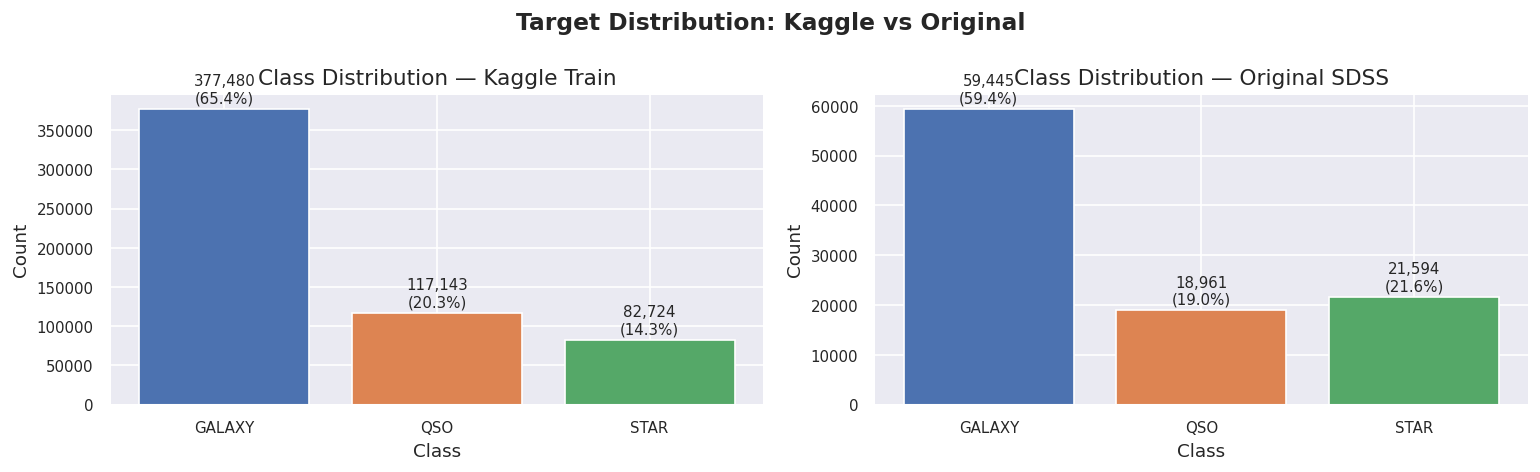


Kaggle imbalance ratio: 4.56
Original imbalance ratio: 3.14


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (df, title) in zip(axes, [
    (train,    'Kaggle Train'),
    (original, 'Original SDSS'),
]):
    counts = df['class'].value_counts().reindex(CLASS_ORDER)
    pcts   = (counts / len(df) * 100).round(1)
    bars   = ax.bar(CLASS_ORDER, counts.values, color=PALETTE, edgecolor='white')
    for bar, cnt, pct in zip(bars, counts.values, pcts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                f'{cnt:,}\n({pct}%)', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Class Distribution — {title}')
    ax.set_ylabel('Count')
    ax.set_xlabel('Class')

plt.suptitle('Target Distribution: Kaggle vs Original', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKaggle imbalance ratio:', round(
    train['class'].value_counts().max() / train['class'].value_counts().min(), 2))
print('Original imbalance ratio:', round(
    original['class'].value_counts().max() / original['class'].value_counts().min(), 2))

# Numeric Stats — Kaggle vs Original

In [9]:
print('=== Kaggle Train — Numeric Stats ===')
display(train[SHARED_NUM].describe().T.round(3))

print('\n=== Original SDSS — Numeric Stats ===')
display(original[SHARED_NUM].describe().T.round(3))

=== Kaggle Train — Numeric Stats ===


,count,mean,std,min,25%,50%,75%,max
alpha,577347.0,181.617,96.243,0.012,132.161,188.681,231.830,360.000
delta,577347.0,21.835,18.934,-17.967,2.474,21.484,36.988,79.158
u,577347.0,22.442,2.018,-0.139,20.977,22.570,23.869,28.253
g,577347.0,21.007,1.795,13.535,19.865,21.468,22.293,27.620
r,577347.0,19.963,1.649,12.579,18.821,20.431,21.164,25.254
i,577347.0,19.379,1.580,11.963,18.307,19.632,20.608,27.911
z,577347.0,19.041,1.584,11.683,17.973,19.189,20.162,26.827
redshift,577347.0,0.723,0.810,-0.010,0.181,0.498,0.881,7.011



=== Original SDSS — Numeric Stats ===


,count,mean,std,min,25%,50%,75%,max
alpha,100000.0,177.629,96.502,0.006,127.518,180.901,233.895,360.000
delta,100000.0,24.135,19.645,-18.785,5.147,23.646,39.902,83.001
u,100000.0,21.980,31.769,-9999.000,20.352,22.179,23.687,32.781
g,100000.0,20.531,31.750,-9999.000,18.965,21.100,22.124,31.602
r,100000.0,19.646,1.855,9.822,18.136,20.125,21.045,29.572
i,100000.0,19.085,1.758,9.470,17.732,19.405,20.396,32.141
z,100000.0,18.669,31.728,-9999.000,17.461,19.005,19.921,29.384
redshift,100000.0,0.577,0.731,-0.010,0.055,0.424,0.704,7.011


# Feature Distribution Comparison — Kaggle vs Original (per column)

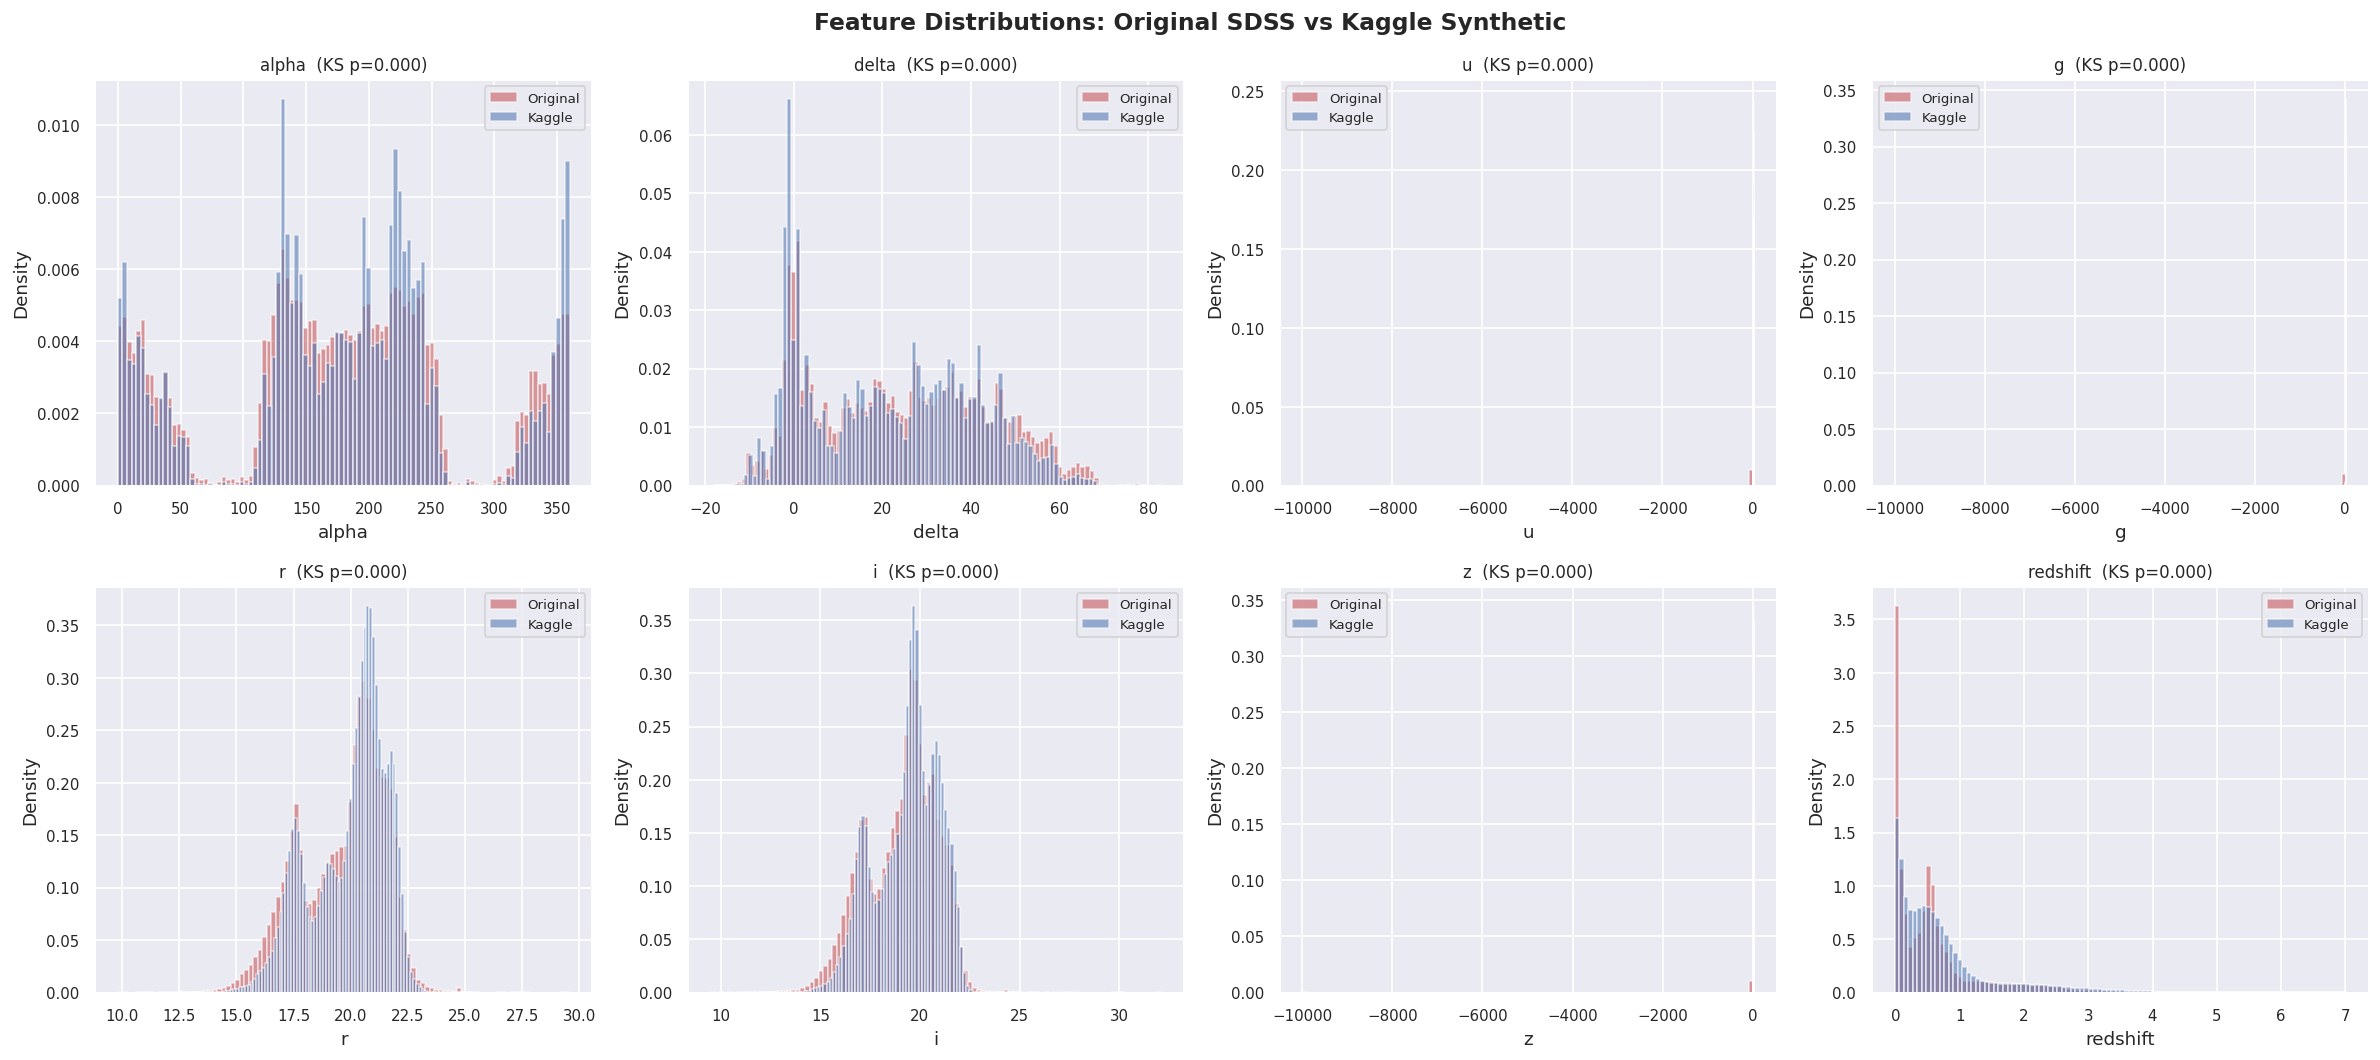

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for idx, col in enumerate(SHARED_NUM):
    ax = axes[idx]
    ax.hist(original[col].dropna(), bins=100, alpha=0.55,
            color='#C44E52', density=True, label='Original')
    ax.hist(train[col].dropna(),    bins=100, alpha=0.55,
            color='#4C72B0', density=True, label='Kaggle')
    ks_stat, p_val = ks_2samp(
        original[col].dropna(), train[col].dropna()
    )
    ax.set_title(f'{col}  (KS p={p_val:.3f})', fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Original SDSS vs Kaggle Synthetic',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Redshift Deep Dive — Kaggle vs Original, per Class

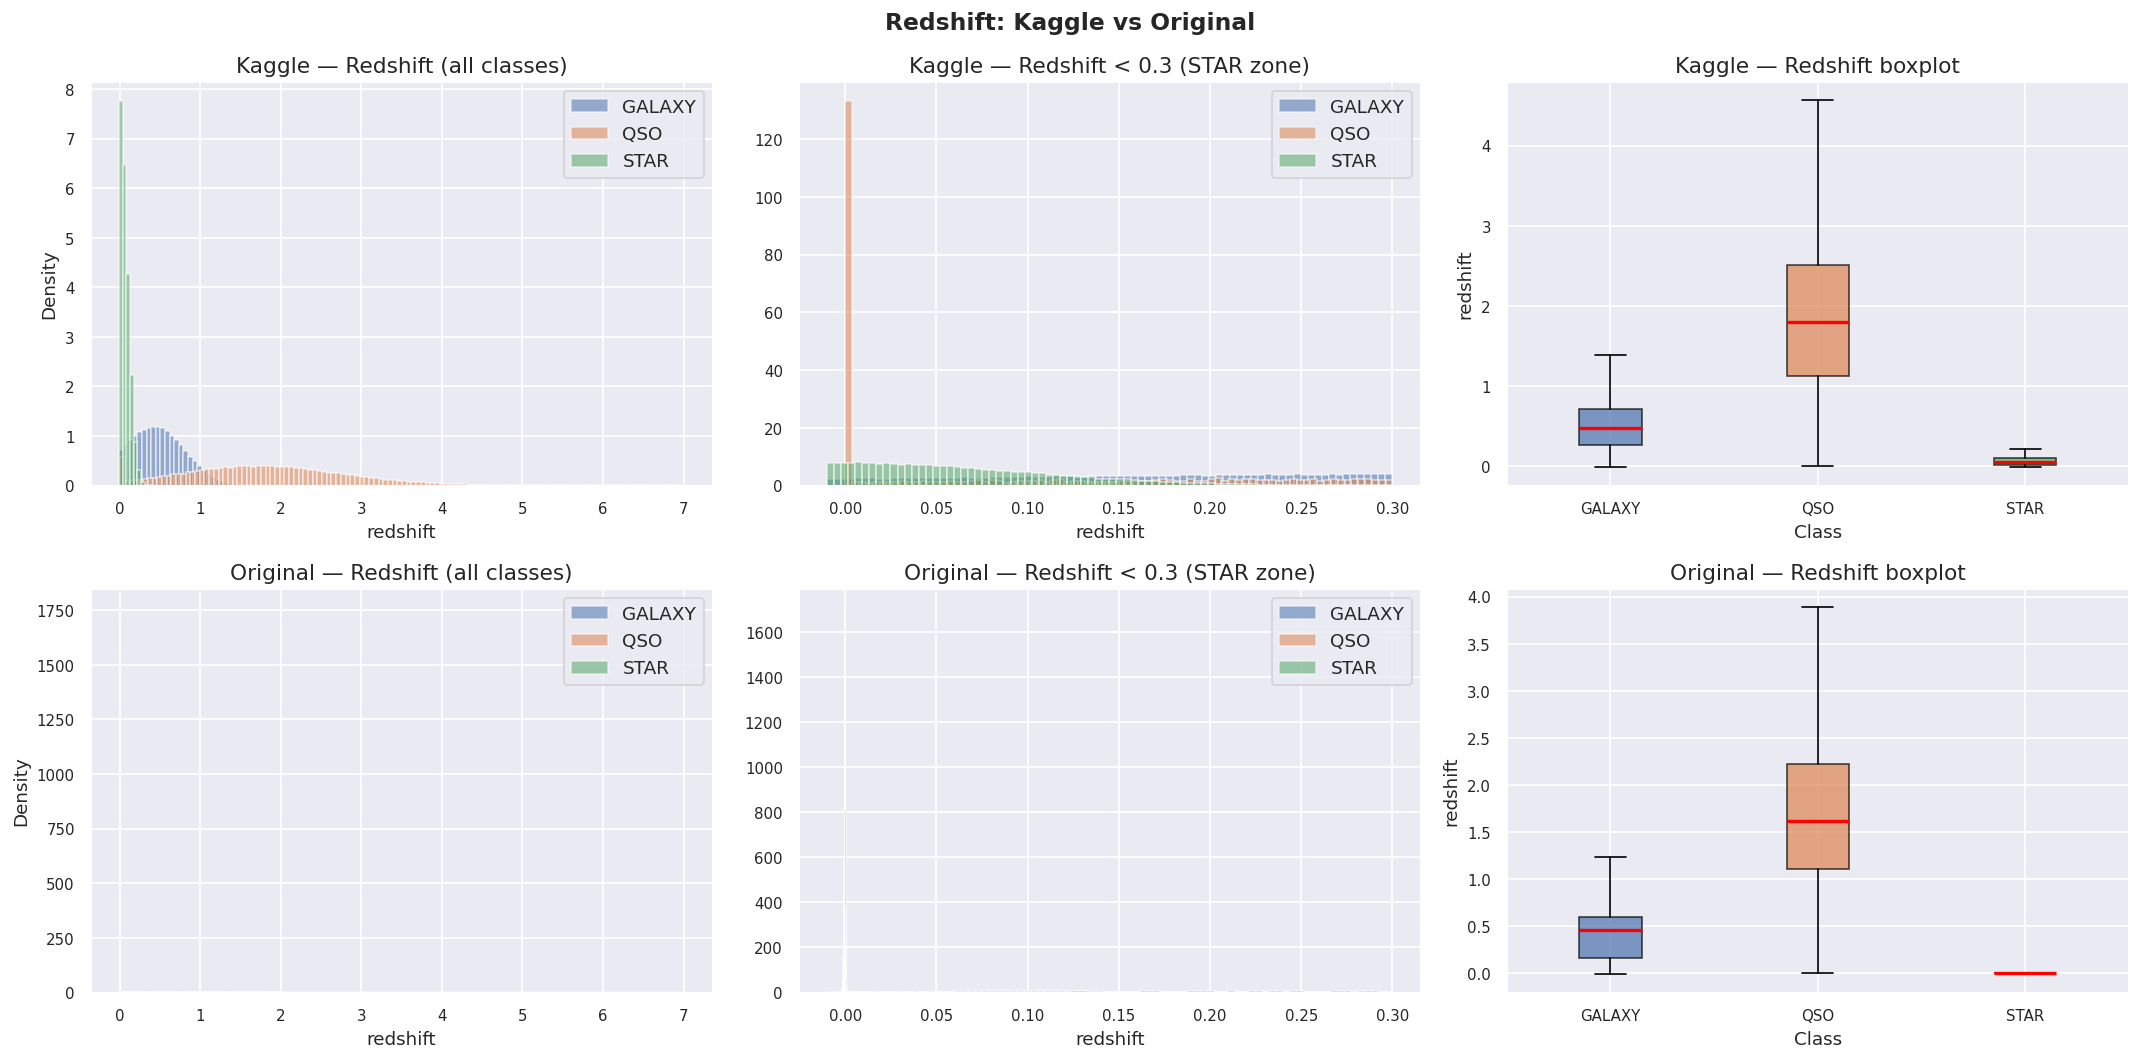


Kaggle — redshift per class:
           count   mean    std   min    25%    50%    75%    max
class                                                           
GALAXY  377480.0  0.509  0.309 -0.01  0.267  0.482  0.715  6.860
QSO     117143.0  1.876  1.070  0.00  1.132  1.799  2.506  7.011
STAR     82724.0  0.068  0.064 -0.01  0.022  0.056  0.102  5.445

Original — redshift per class:
          count   mean    std    min    25%    50%    75%    max
class                                                           
GALAXY  59445.0  0.422  0.265 -0.010  0.165  0.456  0.595  1.996
QSO     18961.0  1.720  0.914  0.000  1.107  1.617  2.220  7.011
STAR    21594.0 -0.000  0.000 -0.004 -0.000 -0.000  0.000  0.004


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for row, (df, label) in enumerate([(train, 'Kaggle'), (original, 'Original')]):
    # All classes together
    ax = axes[row, 0]
    for cls, clr in CLASS_COLORS.items():
        sub = df.loc[df['class'] == cls, 'redshift']
        ax.hist(sub, bins=120, alpha=0.55, color=clr, density=True, label=cls)
    ax.set_title(f'{label} — Redshift (all classes)')
    ax.set_xlabel('redshift')
    ax.set_ylabel('Density')
    ax.legend()

    # STAR zoom
    ax = axes[row, 1]
    for cls, clr in CLASS_COLORS.items():
        sub = df.loc[(df['class'] == cls) & (df['redshift'] < 0.3), 'redshift']
        ax.hist(sub, bins=80, alpha=0.55, color=clr, density=True, label=cls)
    ax.set_title(f'{label} — Redshift < 0.3 (STAR zone)')
    ax.set_xlabel('redshift')
    ax.legend()

    # Boxplot
    ax = axes[row, 2]
    data_by_class = [df.loc[df['class'] == cls, 'redshift'].values for cls in CLASS_ORDER]
    bp = ax.boxplot(data_by_class, patch_artist=True, labels=CLASS_ORDER,
                    showfliers=False)
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for med in bp['medians']:
        med.set_color('red')
        med.set_linewidth(2)
    ax.set_title(f'{label} — Redshift boxplot')
    ax.set_xlabel('Class')
    ax.set_ylabel('redshift')

plt.suptitle('Redshift: Kaggle vs Original', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

for label, df in [('Kaggle', train), ('Original', original)]:
    print(f'\n{label} — redshift per class:')
    print(df.groupby('class')['redshift'].describe().round(3).to_string())

# Can Original Data Be Used as Extra Training Data?

In [12]:
# Check if original's class label set matches exactly
print('Kaggle classes  :', sorted(train['class'].unique()))
print('Original classes:', sorted(original['class'].unique()))

# Check overlap in shared columns — build a combined df
orig_shared = original[SHARED_NUM + ['class']].copy()
train_shared = train[SHARED_NUM + ['class']].copy()

orig_shared['source']  = 'original'
train_shared['source'] = 'kaggle'

combined = pd.concat([orig_shared, train_shared], ignore_index=True)
print(f'\nCombined shape: {combined.shape}')
print(combined['source'].value_counts())
print('\nClass counts in combined:')
print(combined['class'].value_counts())

Kaggle classes  : ['GALAXY', 'QSO', 'STAR']
Original classes: ['GALAXY', 'QSO', 'STAR']

Combined shape: (677347, 10)
source
kaggle      577347
original    100000
Name: count, dtype: int64

Class counts in combined:
class
GALAXY    436925
QSO       136104
STAR      104318
Name: count, dtype: int64


# Kaggle-Only Features — New Categorical Columns

In [13]:
# spectral_type and galaxy_population are NEW — not in original SDSS
NEW_CAT_COLS = ['spectral_type', 'galaxy_population']

for col in NEW_CAT_COLS:
    print(f'\n=== {col} ===')
    print('Unique values:', train[col].unique())
    ct = pd.crosstab(train[col], train['class'], margins=True)
    pct = pd.crosstab(train[col], train['class'], normalize='index').round(3) * 100
    print('\nCounts:')
    print(ct.to_string())
    print('\nRow %:')
    print(pct.to_string())


=== spectral_type ===
Unique values: ['M' 'O/B' 'G/K' 'A/F']

Counts:
class          GALAXY     QSO   STAR     All
spectral_type                               
A/F             24240   61514  36368  122122
G/K             61627   20921  25998  108546
M              288023    3889  11411  303323
O/B              3590   30819   8947   43356
All            377480  117143  82724  577347

Row %:
class          GALAXY   QSO  STAR
spectral_type                    
A/F              19.8  50.4  29.8
G/K              56.8  19.3  24.0
M                95.0   1.3   3.8
O/B               8.3  71.1  20.6

=== galaxy_population ===
Unique values: ['Red_Sequence' 'Blue_Cloud']

Counts:
class              GALAXY     QSO   STAR     All
galaxy_population                               
Blue_Cloud          88962  108274  60546  257782
Red_Sequence       288518    8869  22178  319565
All                377480  117143  82724  577347

Row %:
class              GALAXY   QSO  STAR
galaxy_population             

# Categorical Features — Visual

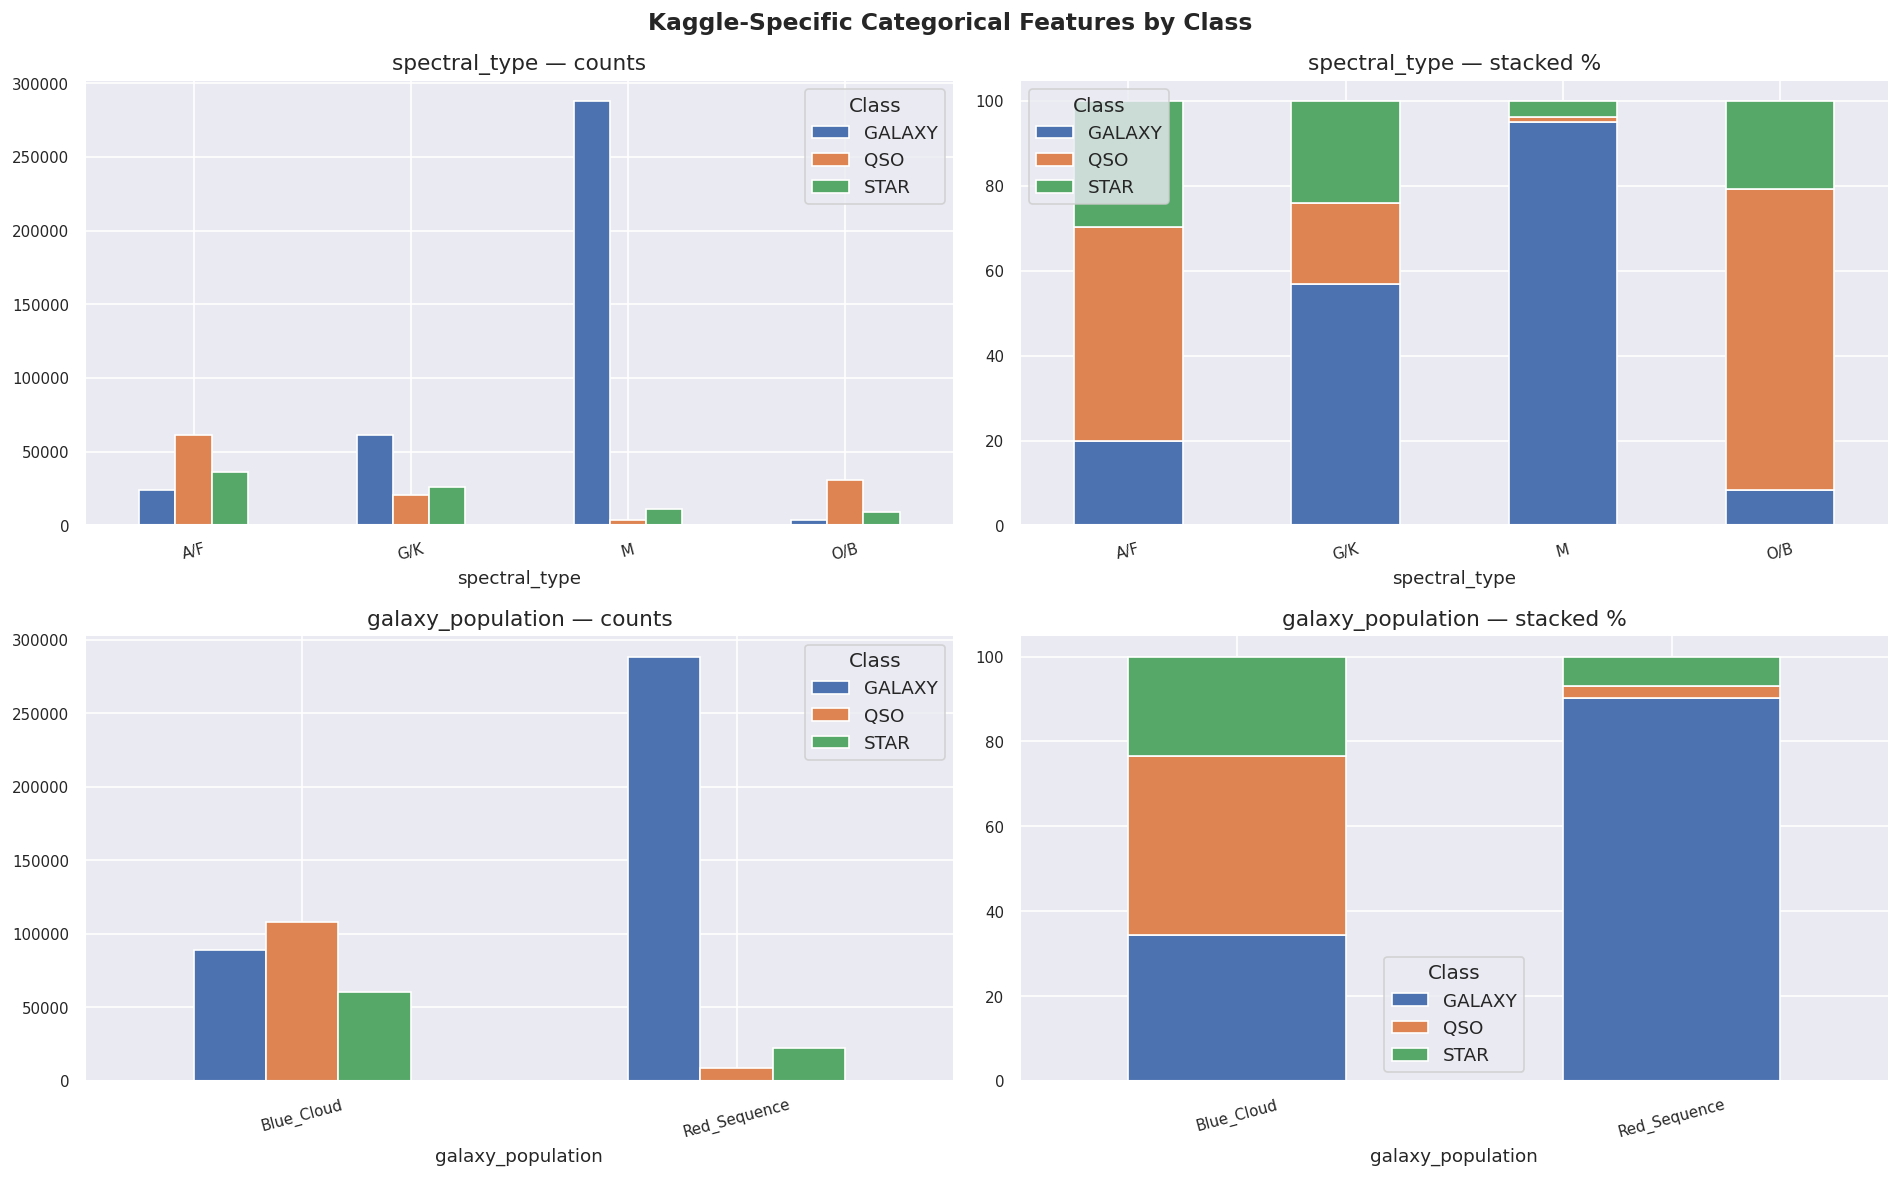

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, col in enumerate(NEW_CAT_COLS):
    counts = train.groupby([col, 'class']).size().unstack(fill_value=0)[CLASS_ORDER]
    pcts   = counts.div(counts.sum(axis=1), axis=0) * 100

    counts.plot(kind='bar', ax=axes[row, 0], color=PALETTE, edgecolor='white')
    axes[row, 0].set_title(f'{col} — counts')
    axes[row, 0].tick_params(axis='x', rotation=15)
    axes[row, 0].legend(title='Class')

    pcts.plot(kind='bar', stacked=True, ax=axes[row, 1], color=PALETTE, edgecolor='white')
    axes[row, 1].set_title(f'{col} — stacked %')
    axes[row, 1].tick_params(axis='x', rotation=15)
    axes[row, 1].legend(title='Class')

plt.suptitle('Kaggle-Specific Categorical Features by Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Color Indices

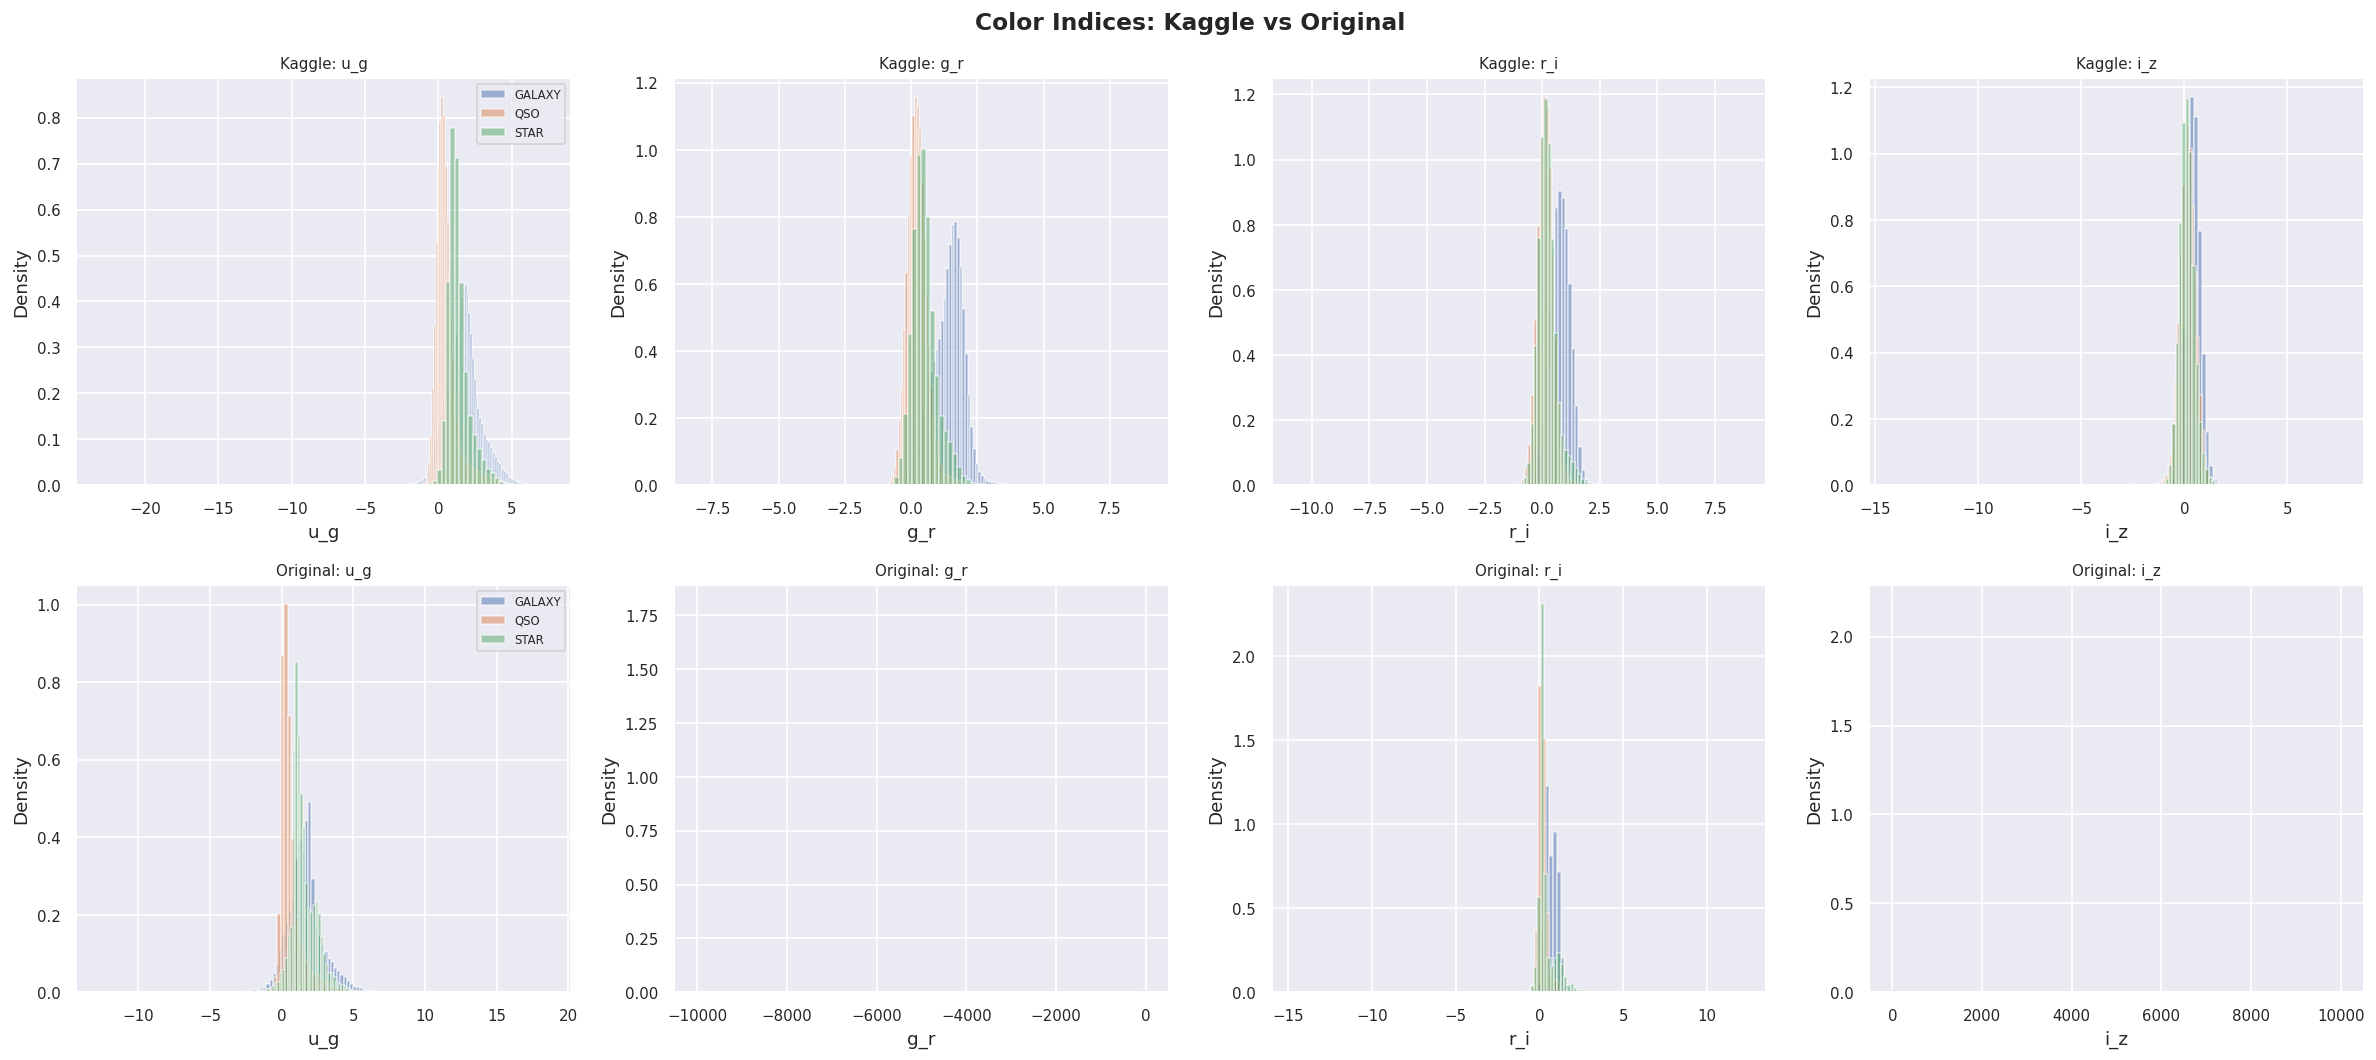

In [15]:
for df in [train, test]:
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']

for df in [original]:
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']

COLOR_COLS = ['u_g', 'g_r', 'r_i', 'i_z']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for col_idx, col in enumerate(COLOR_COLS):
    for row, (df, label) in enumerate([(train, 'Kaggle'), (original, 'Original')]):
        ax = axes[row, col_idx]
        for cls, clr in CLASS_COLORS.items():
            sub = df.loc[df['class'] == cls, col]
            ax.hist(sub, bins=100, alpha=0.5, color=clr, density=True, label=cls)
        ax.set_title(f'{label}: {col}', fontsize=9)
        ax.set_xlabel(col)
        ax.set_ylabel('Density')
        if col_idx == 0:
            ax.legend(fontsize=7)

plt.suptitle('Color Indices: Kaggle vs Original', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation Matrix — Kaggle Train

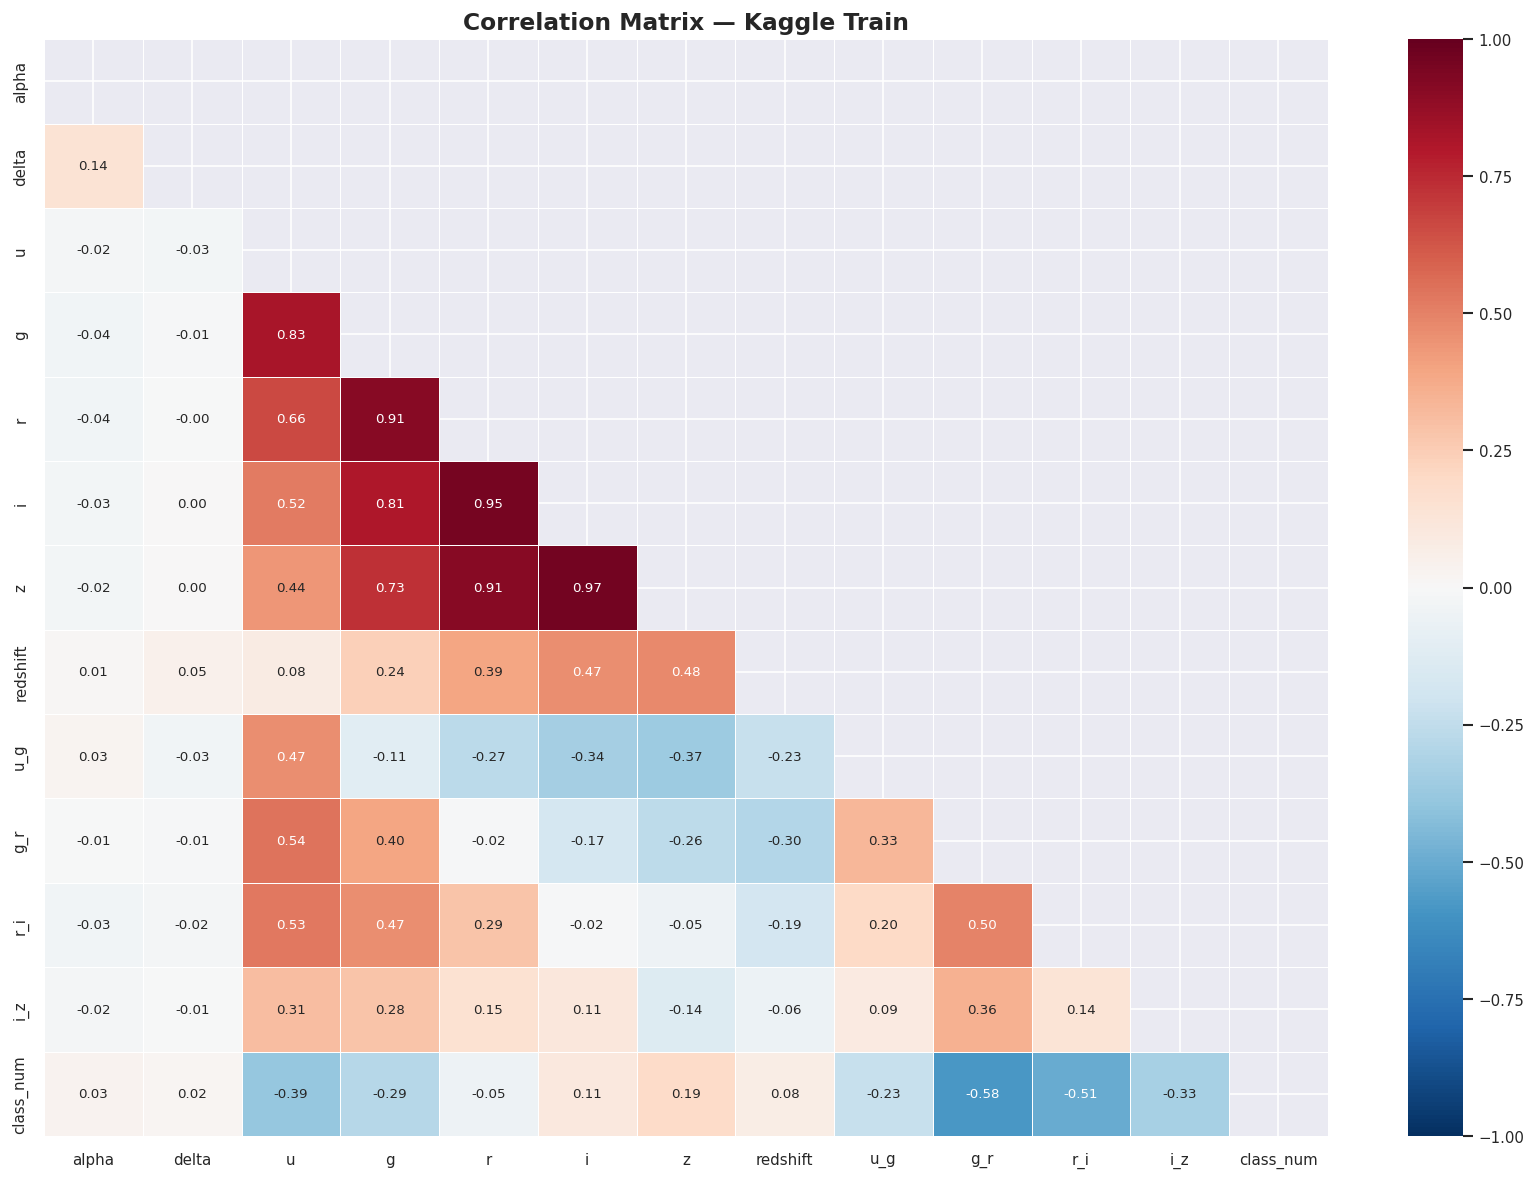


Correlation with class_num (|r|, descending):
g_r         0.583357
r_i         0.507789
u           0.385667
i_z         0.332746
g           0.285010
u_g         0.233462
z           0.190467
i           0.107635
redshift    0.077758
r           0.049845
alpha       0.033585
delta       0.017359


In [16]:
train['class_num'] = train['class'].map({'GALAXY': 0, 'QSO': 1, 'STAR': 2})

corr_cols = SHARED_NUM + COLOR_COLS + ['class_num']
corr = train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Kaggle Train', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelation with class_num (|r|, descending):')
print(corr['class_num'].drop('class_num').abs().sort_values(ascending=False).to_string())

# Mutual Information — Kaggle Train

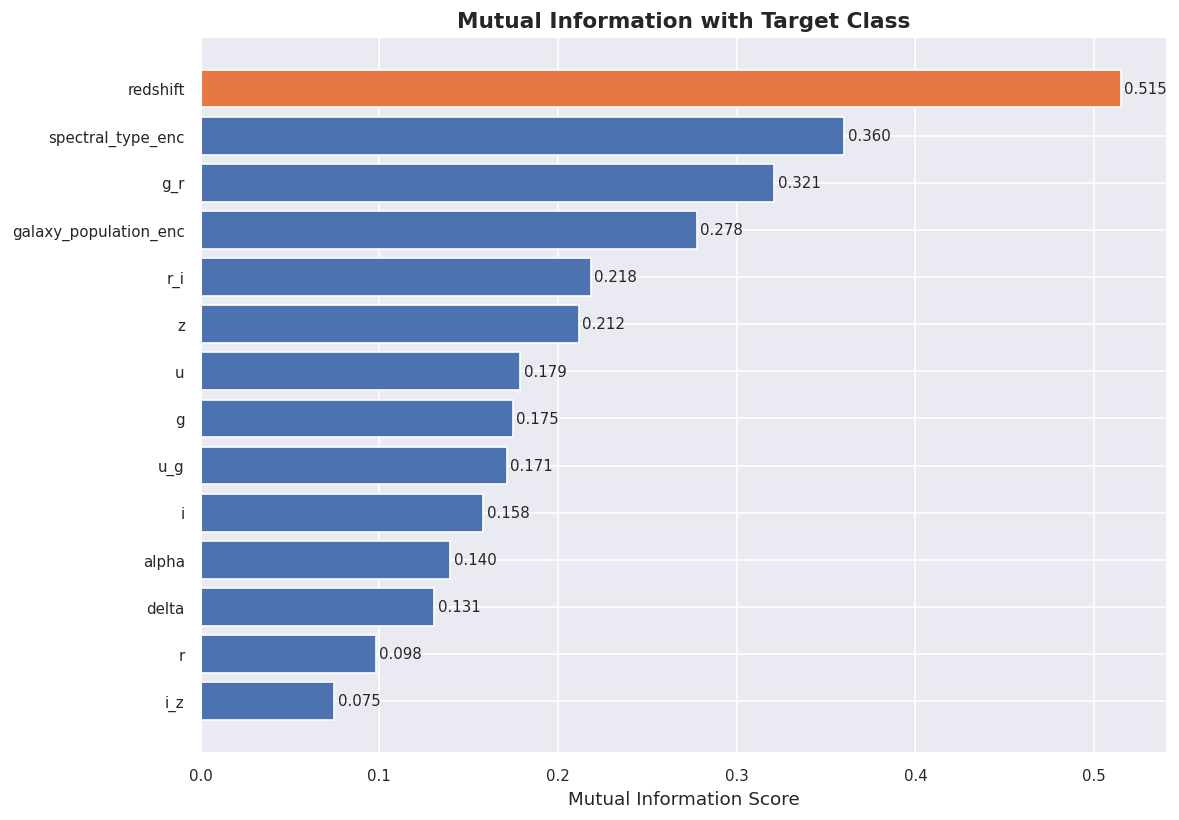


MI ranking:
redshift                 0.514987
spectral_type_enc        0.360320
g_r                      0.321156
galaxy_population_enc    0.277715
r_i                      0.218324
z                        0.211520
u                        0.178886
g                        0.174581
u_g                      0.171346
i                        0.158246
alpha                    0.139562
delta                    0.130772
r                        0.097933
i_z                      0.074759


In [17]:
le = LabelEncoder()
train_enc = train.copy()
train_enc['spectral_type_enc']     = le.fit_transform(train['spectral_type'])
train_enc['galaxy_population_enc'] = le.fit_transform(train['galaxy_population'])

MI_COLS = SHARED_NUM + COLOR_COLS + ['spectral_type_enc', 'galaxy_population_enc']

X = train_enc[MI_COLS].fillna(0)
y = le.fit_transform(train_enc['class'])

mi = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi, index=MI_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ['#E87843' if v == mi_series.max() else '#4C72B0' for v in mi_series.values]
bars = ax.barh(mi_series.index, mi_series.values, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, mi_series.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Mutual Information Score')
ax.set_title('Mutual Information with Target Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nMI ranking:')
print(mi_series.sort_values(ascending=False).to_string())

# Redshift Threshold Baseline

In [18]:
def redshift_rule(z):
    if z < 0.15:  return 'STAR'
    elif z > 1.0: return 'QSO'
    else:         return 'GALAXY'

train['redshift_pred'] = train['redshift'].apply(redshift_rule)
ba = balanced_accuracy_score(train['class'], train['redshift_pred'])
print(f'Simple redshift-only rule — Balanced Accuracy: {ba:.4f}')
print()
print(classification_report(train['class'], train['redshift_pred']))
train.drop(columns=['redshift_pred'], inplace=True)

Simple redshift-only rule — Balanced Accuracy: 0.8319

              precision    recall  f1-score   support

      GALAXY       0.92      0.80      0.85    377480
         QSO       0.78      0.79      0.79    117143
        STAR       0.58      0.90      0.71     82724

    accuracy                           0.81    577347
   macro avg       0.76      0.83      0.78    577347
weighted avg       0.84      0.81      0.82    577347



# Overlap Zones Analysis


=== STAR–GALAXY overlap (redshift 0.05–0.25) ===
Rows in zone: 118,080
class
GALAXY    71343
STAR      44432
QSO        2305
Name: count, dtype: int64

spectral_type × class:
class          GALAXY   QSO   STAR
spectral_type                     
A/F              5212  1214  19451
G/K             17187   543  14029
M               48382    86   6153
O/B               562   462   4799

galaxy_population × class:
class              GALAXY   QSO   STAR
galaxy_population                     
Blue_Cloud          12162  2241  32486
Red_Sequence        59181    64  11946

=== GALAXY–QSO overlap (redshift 0.80–1.20) ===
Rows in zone: 73,814
class
GALAXY    59728
QSO       14079
STAR          7
Name: count, dtype: int64

spectral_type × class:
class          GALAXY   QSO  STAR
spectral_type                    
A/F              5855  7569     3
G/K              9411  2879     2
M               43369   320     1
O/B              1093  3311     1

galaxy_population × class:
class              GALAX

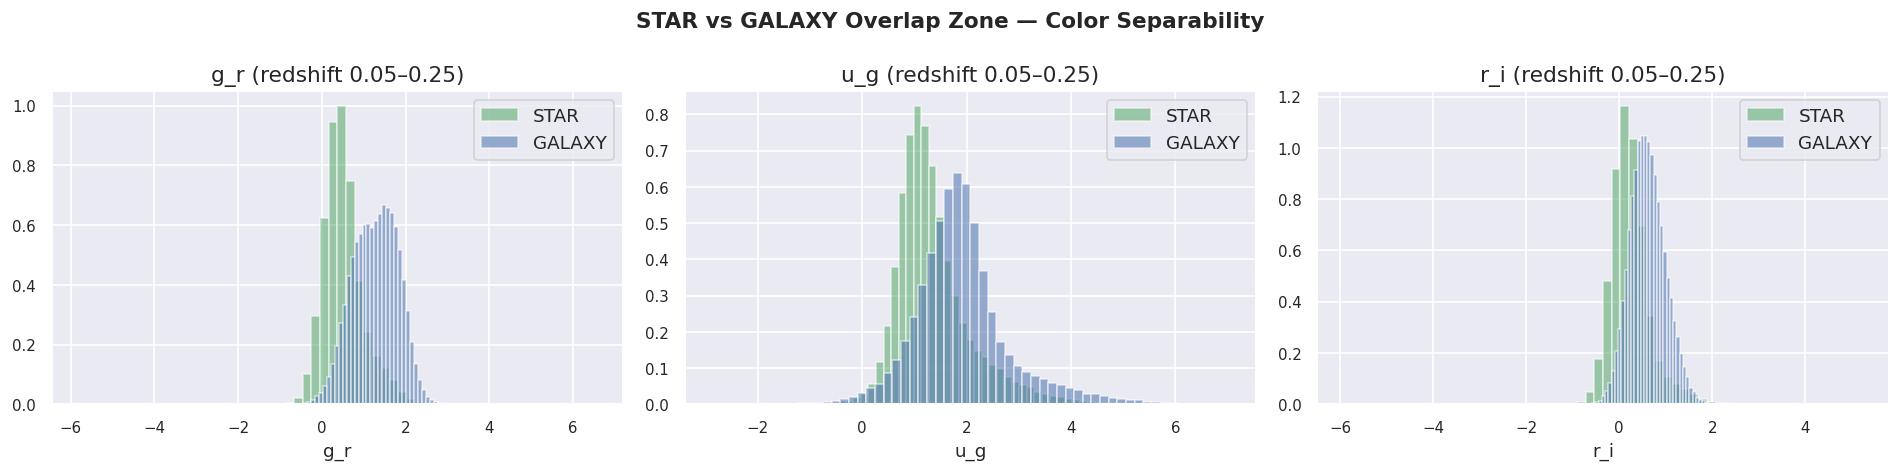

In [19]:
zones = {
    'STAR–GALAXY overlap (redshift 0.05–0.25)': (0.05, 0.25),
    'GALAXY–QSO overlap (redshift 0.80–1.20)':  (0.80, 1.20),
}

for zone_name, (lo, hi) in zones.items():
    zone = train[(train['redshift'] >= lo) & (train['redshift'] <= hi)]
    print(f'\n=== {zone_name} ===')
    print(f'Rows in zone: {len(zone):,}')
    print(zone['class'].value_counts())
    print('\nspectral_type × class:')
    print(pd.crosstab(zone['spectral_type'], zone['class']))
    print('\ngalaxy_population × class:')
    print(pd.crosstab(zone['galaxy_population'], zone['class']))

# Visual: what separates STAR from GALAXY in the overlap zone?
overlap_sg = train[
    (train['redshift'] >= 0.05) & (train['redshift'] <= 0.25) &
    (train['class'].isin(['STAR', 'GALAXY']))
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['g_r', 'u_g', 'r_i']):
    for cls in ['STAR', 'GALAXY']:
        sub = overlap_sg[overlap_sg['class'] == cls][col]
        ax.hist(sub, bins=60, alpha=0.55, color=CLASS_COLORS[cls], density=True, label=cls)
    ax.set_title(f'{col} (redshift 0.05–0.25)')
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle('STAR vs GALAXY Overlap Zone — Color Separability',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Train vs Test Covariate Shift

KS test: Train vs Test

  alpha       : KS=0.0021, p=0.4353
  delta       : KS=0.0014, p=0.8982
  u           : KS=0.0009, p=0.9994
  g           : KS=0.0018, p=0.6548
  r           : KS=0.0017, p=0.7159
  i           : KS=0.0024, p=0.2609
  z           : KS=0.0028, p=0.1434
  redshift    : KS=0.0023, p=0.3343
  u_g         : KS=0.0019, p=0.5645
  g_r         : KS=0.0019, p=0.5889
  r_i         : KS=0.0015, p=0.8531
  i_z         : KS=0.0023, p=0.3137


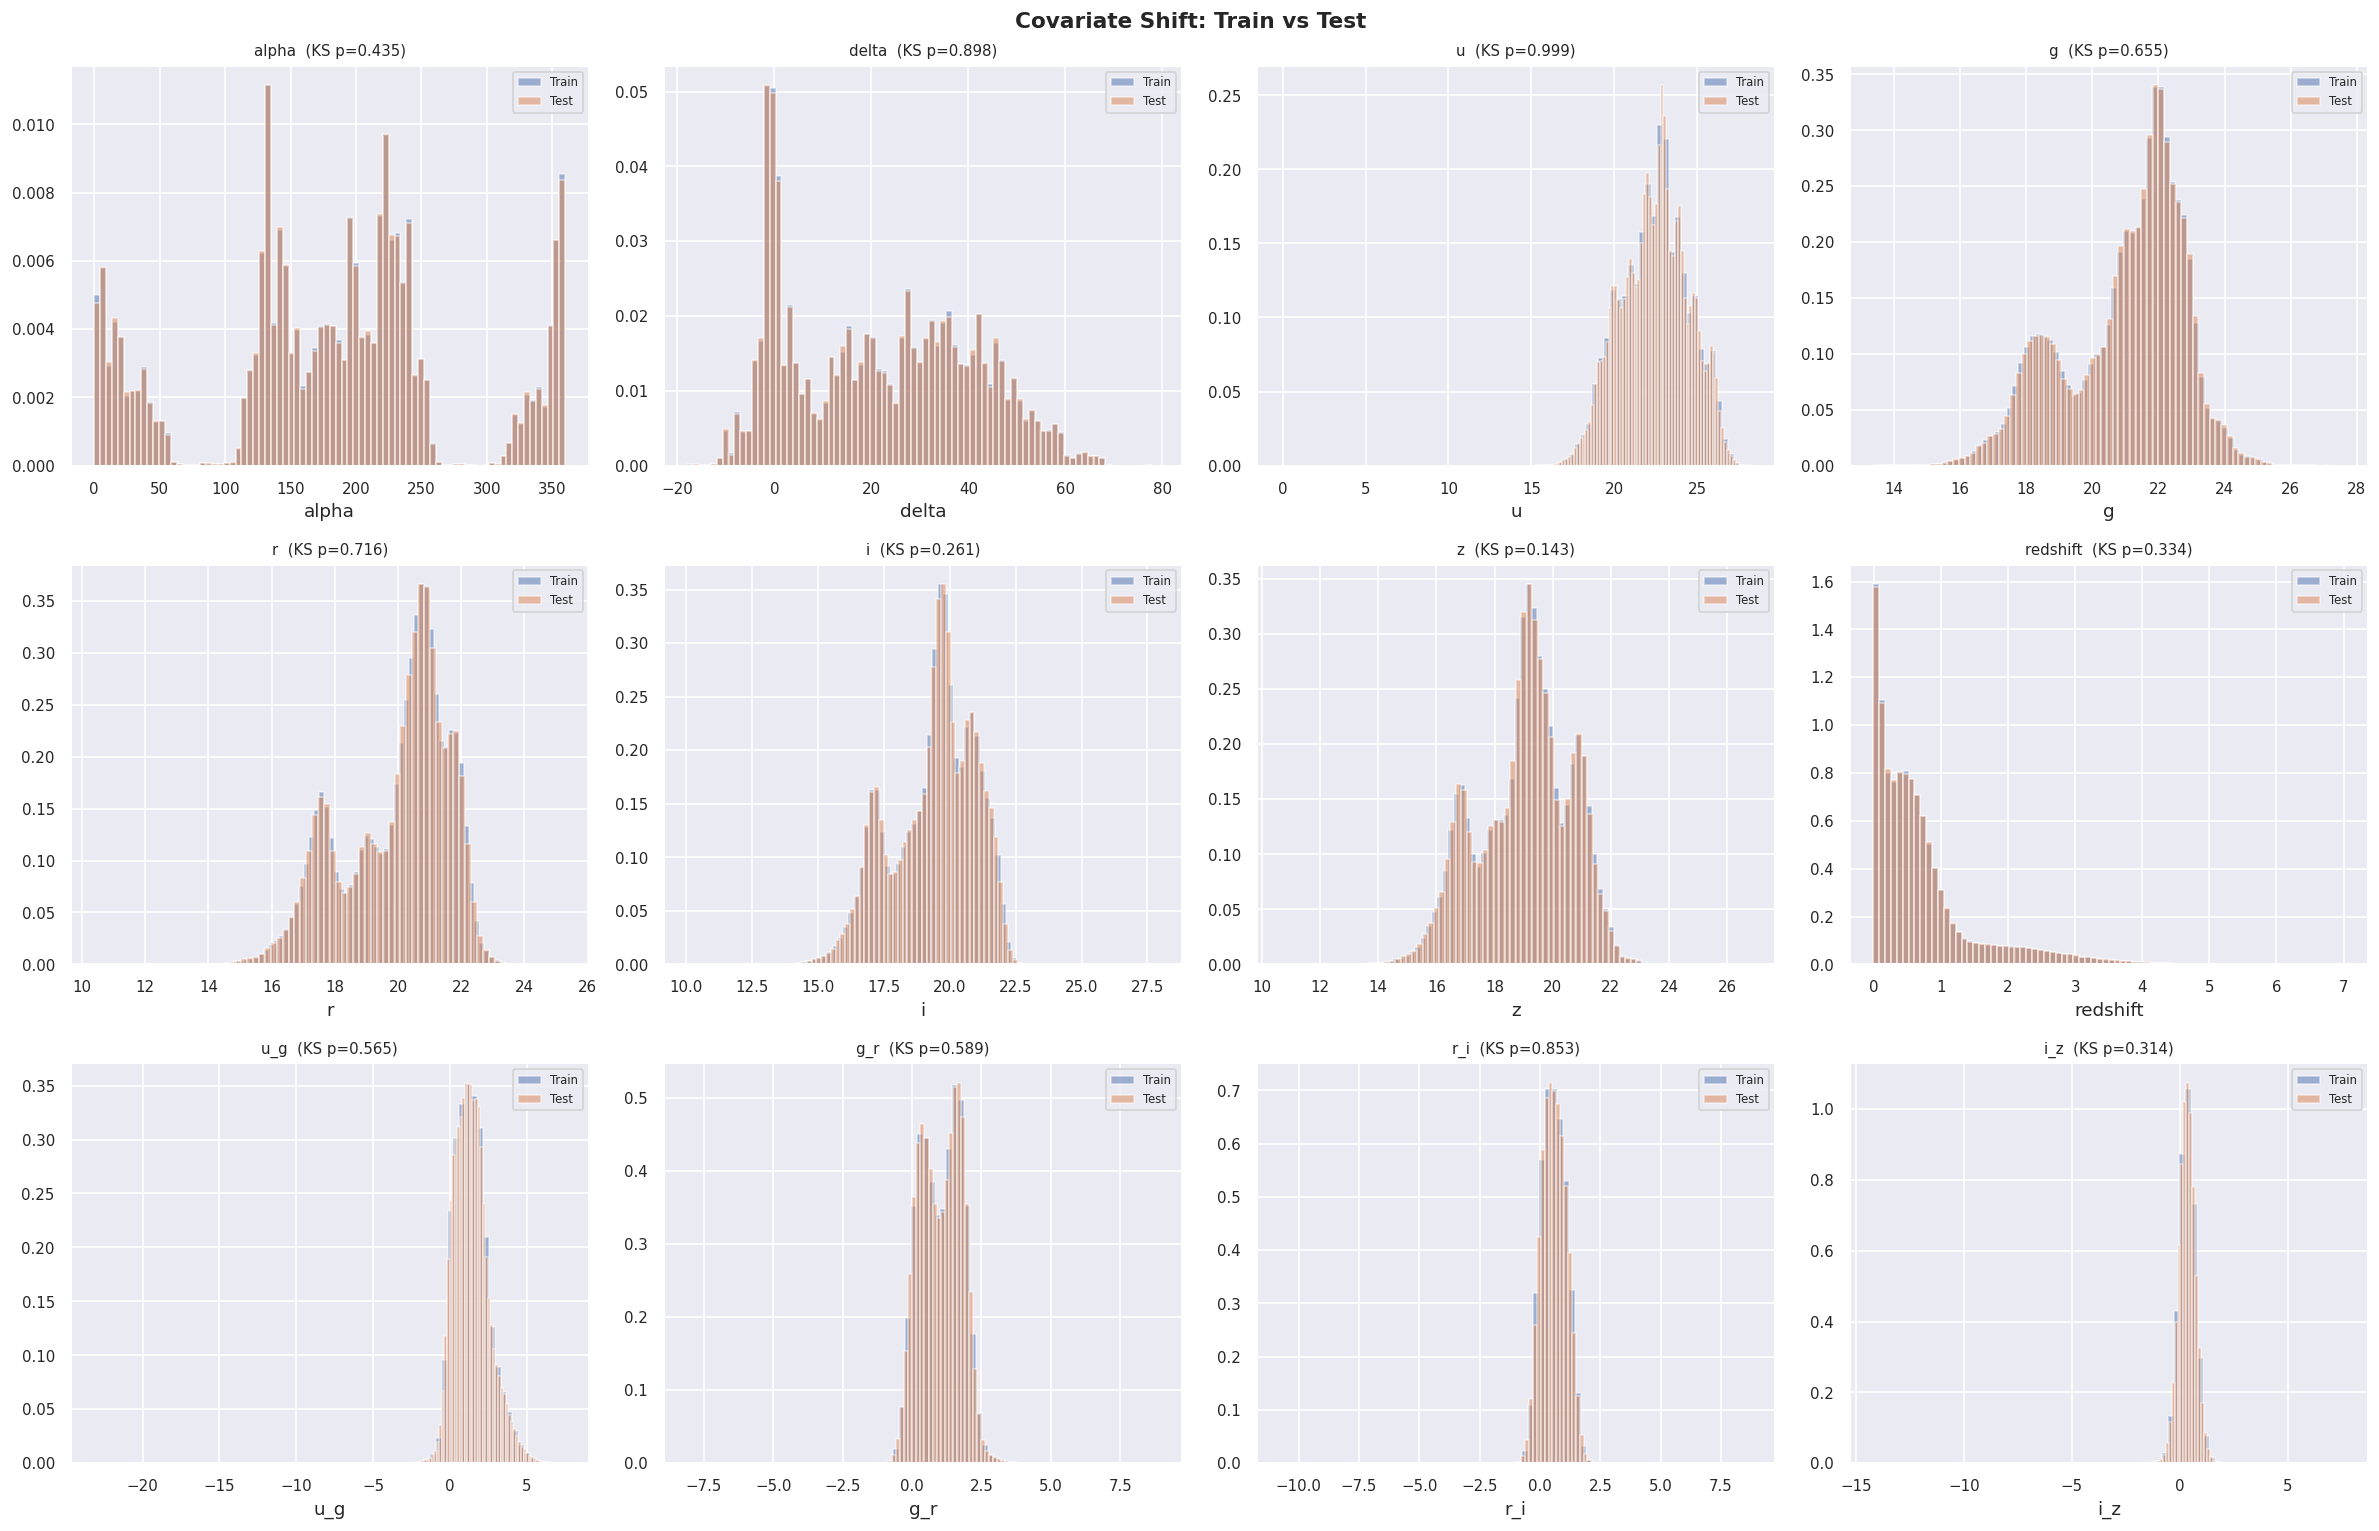

In [20]:
CHECK_COLS = SHARED_NUM + COLOR_COLS

fig, axes = plt.subplots(3, 4, figsize=(20, 13))
axes = axes.flatten()

print('KS test: Train vs Test\n')
for idx, col in enumerate(CHECK_COLS):
    ax = axes[idx]
    ax.hist(train[col], bins=80, alpha=0.5, color='#4C72B0', density=True, label='Train')
    ax.hist(test[col],  bins=80, alpha=0.5, color='#DD8452', density=True, label='Test')
    ks_stat, p_val = ks_2samp(train[col].dropna(), test[col].dropna())
    ax.set_title(f'{col}  (KS p={p_val:.3f})', fontsize=9)
    ax.set_xlabel(col)
    ax.legend(fontsize=7)
    flag = '  ⚠' if p_val < 0.05 else ''
    print(f'  {col:12s}: KS={ks_stat:.4f}, p={p_val:.4f}{flag}')

for idx in range(len(CHECK_COLS), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Covariate Shift: Train vs Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Pairplot — Top Features (sampled)

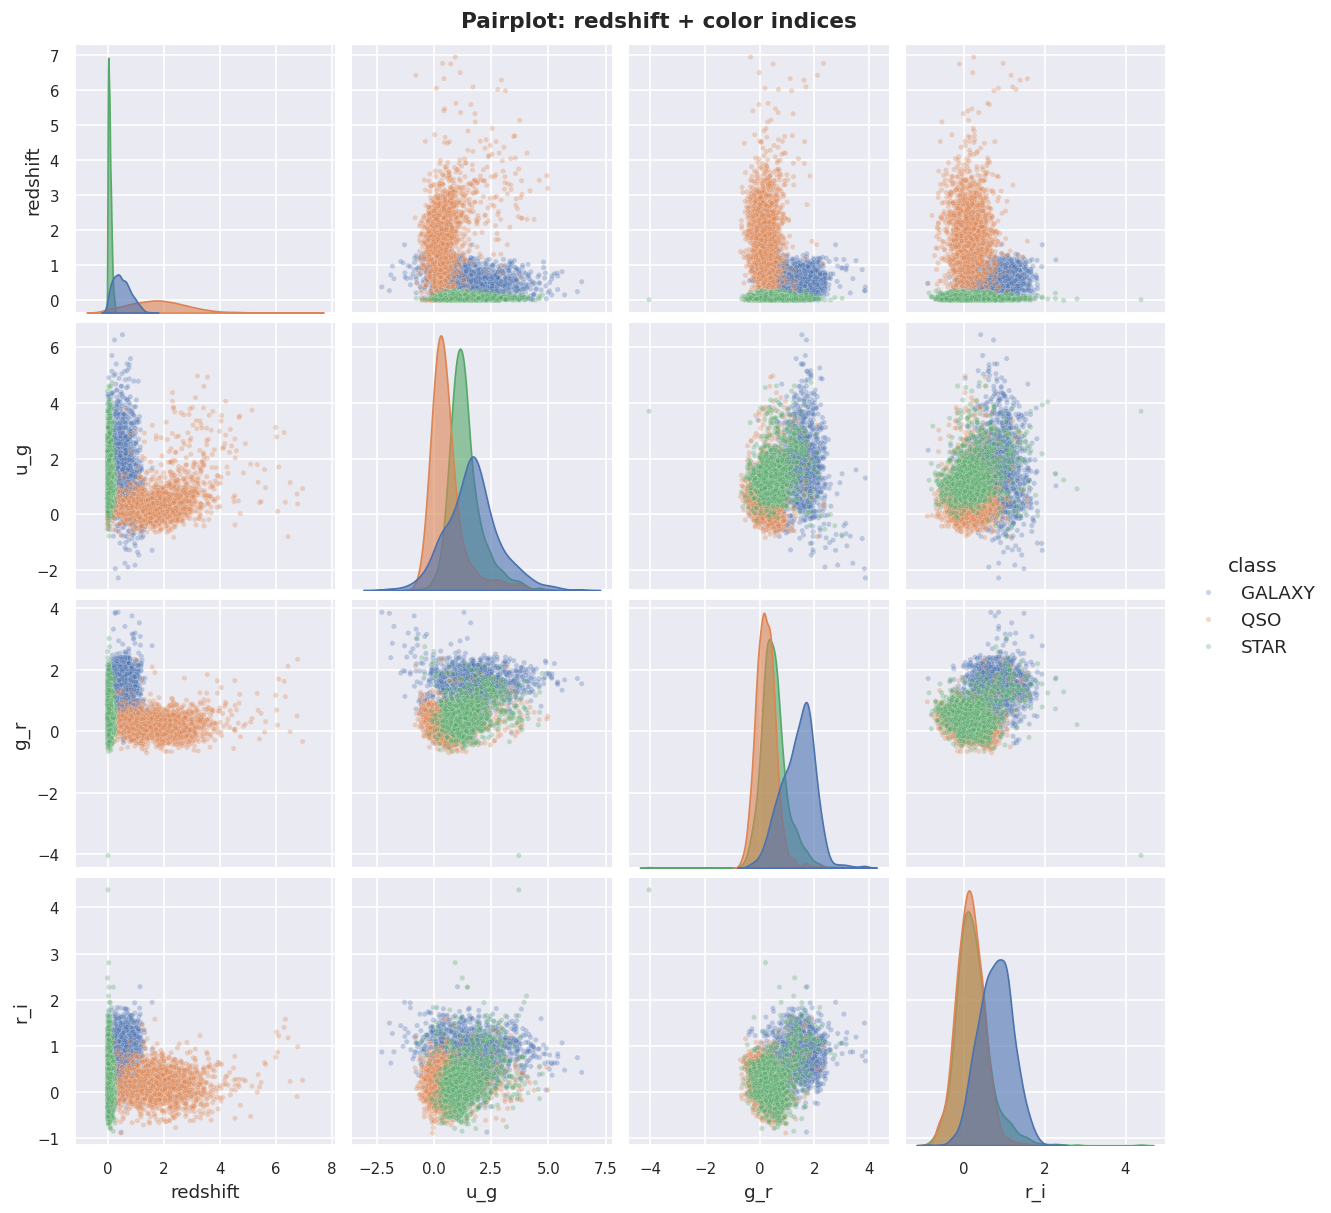

In [21]:
PAIR_COLS = ['redshift', 'u_g', 'g_r', 'r_i', 'class']

pair_sample = train.groupby('class', group_keys=False).apply(
    lambda x: x.sample(min(1500, len(x)), random_state=42)
)[PAIR_COLS]

g = sns.pairplot(
    pair_sample, hue='class', palette=CLASS_COLORS,
    hue_order=CLASS_ORDER,
    plot_kws={'alpha': 0.3, 's': 10},
    diag_kind='kde', diag_kws={'alpha': 0.6}
)
g.fig.suptitle('Pairplot: redshift + color indices', y=1.01,
               fontsize=13, fontweight='bold')
plt.show()

# Check for Blueshift (Negative Redshift)

In [22]:
print("\n=== Objects with Negative Redshift (Blueshift) ===")
neg_redshift = train[train['redshift'] < 0]
print(f"Total rows with negative redshift: {len(neg_redshift)}")
if len(neg_redshift) > 0:
    print(neg_redshift['class'].value_counts())
    
    # Create a boolean flag feature
    for df in [train, test, original]:
        df['is_blueshift'] = (df['redshift'] < 0).astype(int)


=== Objects with Negative Redshift (Blueshift) ===
Total rows with negative redshift: 8957
class
STAR      6498
GALAXY    2459
Name: count, dtype: int64


# Non-Adjacent Color Indices

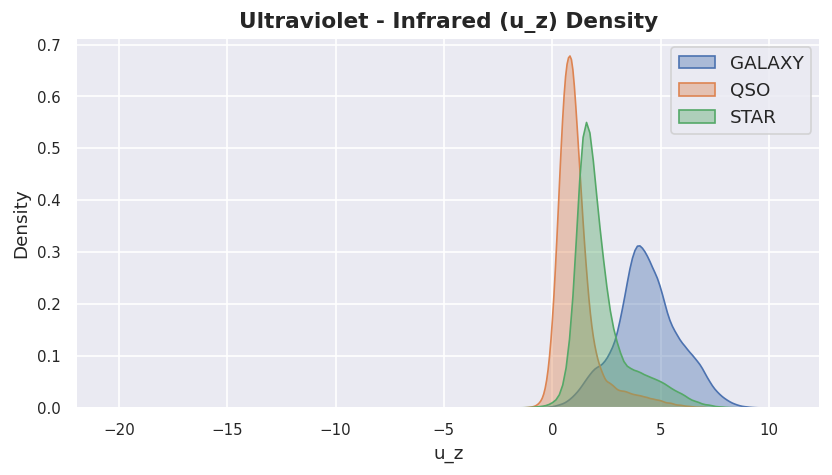

In [23]:
for df in [train, test, original]:
    df['u_z'] = df['u'] - df['z']  # Extreme ends
    df['u_r'] = df['u'] - df['r']
    
# Plot u_z just to see the separation
plt.figure(figsize=(8, 4))
for cls, clr in CLASS_COLORS.items():
    sns.kdeplot(data=train[train['class'] == cls], x='u_z', 
                color=clr, label=cls, fill=True, alpha=0.4)
plt.title('Ultraviolet - Infrared (u_z) Density', fontweight='bold')
plt.legend()
plt.show()

# Astronomical Feature Engineering: Cartesian Coordinates

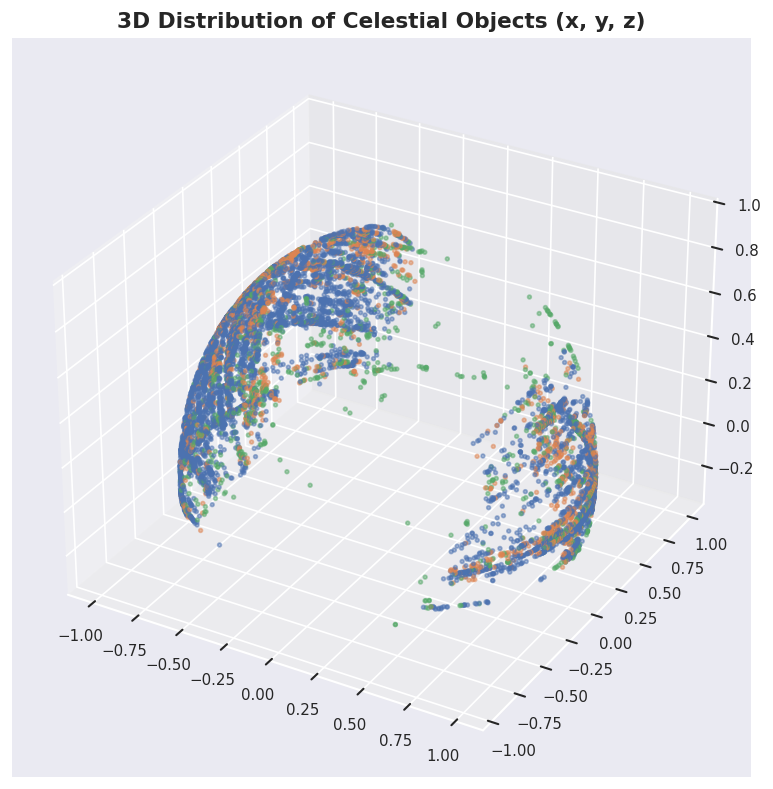

In [24]:
def add_cartesian_coords(df):
    # Convert angles from degrees to radians
    alpha_rad = np.radians(df['alpha'])
    delta_rad = np.radians(df['delta'])
    
    # Spherical to Cartesian transformation
    df['cart_x'] = np.cos(delta_rad) * np.cos(alpha_rad)
    df['cart_y'] = np.cos(delta_rad) * np.sin(alpha_rad)
    df['cart_z'] = np.sin(delta_rad)
    return df

for df in [train, test, original]:
    df = add_cartesian_coords(df)

# Plot the new coordinates
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sample = train.sample(10000, random_state=42) # Sample for performance
colors = sample['class'].map(CLASS_COLORS)

ax.scatter(sample['cart_x'], sample['cart_y'], sample['cart_z'], 
           c=colors, alpha=0.5, s=5)
ax.set_title("3D Distribution of Celestial Objects (x, y, z)", fontweight='bold')
plt.show()